# Margin-Based Models - Linear SVM and SGD

Both models draw a straight boundary between sarcastic and non-sarcastic comments and try to keep the widest possible gap (margin) between the boundary and nearest examples. Their raw output is a score (which is the distance from the boundary). Score > 0 means "sarcastic". 

Pipeline load data → build features (TF-IDF, lexicon, surface) → compare feature sets → tune hyper-parameters on validation
→ retrain on the full train set → evaluate **once** on test → test on other datasets → save results.

## 1. Setup

import paths

In [ ]:
from __future__ import annotations

import hashlib, json, re, sys, time, warnings
from collections import Counter
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (accuracy_score, average_precision_score,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

import scipy.sparse as sp

warnings.filterwarnings("ignore")

# Execution Parameters
QUICK = False
FORCE_RETRAIN = False
FINAL_FULL_TRAIN = not QUICK 
SEED = 3244
MAX_TFIDF_FEATURES = 500_000

# Location of Project Root Directory 
ROOT = Path.cwd()
while not (ROOT / "data" / "splits").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "data" / "splits").exists(), "run pipeline/notebooks/01-04 first"
sys.path.insert(0, str(ROOT / "pipeline"))
from load import (load_split, load_lexicon, MODEL_SAFE_FEATURES, text_column, context_column)

# Define Output Directories
RESULTS = ROOT / "results" / "margin-based"
FIGURES = ROOT / "figures" / "margin-based"
MODELS  = ROOT / "modelling" / "margin-based"
for d in (RESULTS, FIGURES, MODELS):
    d.mkdir(parents=True, exist_ok=True)


# Constraints & Dataset Parameters
TRAIN_ROWS, VAL_ROWS = (20_000, 8_000) if QUICK else (200_000, 60_000)
N_UNIGRAMS, N_BIGRAMS, MIN_TERM_COUNT = 220, 80, 200
TARGET_PRECISION = 0.75
TRANSFER_TARGETS = ["figlang_reddit", "figlang_twitter",
                    "tweeteval_irony", "news_headlines"]


# Vocabulary limits for TfidfVectorizer 
MAX_TFIDF_FEATURES = 500_000  
N_UNIGRAMS = 220
N_BIGRAMS = 80
MIN_TERM_COUNT = 200

print(f"root      {ROOT}")
print(f"mode  {'QUICK' if QUICK else 'FULL'}   tuning train={TRAIN_ROWS:,} val={VAL_ROWS:,}   final on full train: {FINAL_FULL_TRAIN}")

root      /Users/sufiya/Desktop/cs3244_group1
mode  FULL   tuning train=200,000 val=60,000   final on full train: True


In [40]:
# Record library versions so results can be reproduced
import importlib.metadata as md_
VERSIONS = {p: md_.version(p) for p in
            ["scikit-learn", "pandas", "numpy", "joblib"]}
VERSIONS["python"] = sys.version.split()[0]
pd.Series(VERSIONS).to_frame("version")

,version
scikit-learn,1.8.0
pandas,3.0.0
numpy,2.4.1
joblib,1.5.3
python,3.12.2


## 2. Load Data

Uses `sarc_random` (balanced ~50/50). To keep the many tuning runs fast, hyper-parameters are tuned on a **subsample**
(200k train / 60k validation). The **final** models are retrained on the full training set.

In [41]:
# Load data split 
train_full, val_full, test = load_split("sarc_random")
rng = np.random.default_rng(SEED)

def subsample(df, n):
    return df if n >= len(df) else df.iloc[rng.choice(len(df), n, replace=False)].reset_index(drop=True)

# Subsample dataset for fast feature comparison and hyperparameter tuning
train = subsample(train_full, TRAIN_ROWS) 
val   = subsample(val_full,   VAL_ROWS)

print(f"tuning : train {len(train):,}   val {len(val):,}")
print(f"full   : train {len(train_full):,}   val {len(val_full):,}   test {len(test):,}")
print(f"sarcastic rate - train {train.label.mean():.4f}   test {test.label.mean():.4f}")   # should be ~0.5
train[["label", "comment_clean", "parent_clean", "subreddit"]].head()

tuning : train 200,000   val 60,000
full   : train 639,638   val 137,066   test 137,065
sarcastic rate - train 0.5080   test 0.5107


,label,comment_clean,parent_clean,subreddit
0,1,"Yep, even the women.",Big dick?,AskMen
1,1,DEAL ME IN!,It really will be about tone. The fact that th...,politics
2,1,"Yeah, but your mum doesn't count dude.","""The screenplay features an original, heartfel...",Screenwriting
3,1,A Tight end obviously,Who do we draft to fix the Offensive line? Wha...,detroitlions
4,0,Like half a month actually.,they had even lost to the same astralis in kat...,GlobalOffensive


## 3. Feature engineering

Each comment is converted into one long row of numbers built from three blocks of clues.

| Block | Size | What it captures | Why it is included |
|---|---|---|---|
| `tfidf` | up to 500,000 | Which words and 2-word phrases appear | Linear SVMs handle huge sparse matrices well |
| `lex` | 16 | Emotion and sentiment of the reply, and how it clashes with the parent | Sarcasm is often a positive reply to a negative comment |
| `surf` | 22 | Writing style: exclamation marks, interjections, length, ... | EDA found these carry real signal, and TF-IDF cannot see punctuation |

Every block is fitted on the training set only. Vocabulary, word weights and scaling statistics are learned from train, then applied unchanged to validation and test. 


### Block 1: TF-IDF (the words)

Every word and every 2-word phrase gets its own column. A comment only has non-zero values for the phrases it contains (`oh`, `great`, `oh great`, ...), so almost the whole row is zeros. It is stored as a **sparse matrix** to save memory.

Each non-zero value is **TF x IDF**:
- **TF (term frequency):** how much the phrase appears in this comment. We use `sublinear_tf=True`, so a word repeated 10 times counts for less than 10 times as much.
- **IDF (inverse document frequency):** about log(total comments / comments containing the phrase). Rare, distinctive phrases such as "obviously" score high, and words in nearly every comment, such as "the", score low. (scikit-learn uses a slightly smoothed version of this formula.)
- Each row is then **L2-normalised**, so a long comment does not outweigh a short one, and values stay small.

Limitation: TF-IDF lowercases everything and ignores punctuation, so it cannot see "!" or ALL CAPS, which is addressed in block 3.

### Block 2: Lexicon features

Built from two word lists: NRC (which emotions a word carries) and VADER (how positive or negative a word is).

- **NRC (10):** for each emotion (anger, joy, fear, trust, ...), the share of the comment's words on that emotion's list. 
- **VADER (4):** the reply's average sentiment, its share of positive words, its share of negative words, and the **parent's** average sentiment.
- **Incongruity (2):** the sarcasm-specific part.
  - `incongruity_pos_reply_neg_parent` = 1 if the reply is positive (above 0.05) and the parent is negative (below -0.05). 
  - `incongruity_signed` = reply sentiment x parent sentiment. It is negative when the two disagree, and more negative the bigger the clash.


### Block 3: Surface features

The 22 `MODEL_SAFE_FEATURES` from the cleaning stage: counts of exclamation marks, question marks, ellipses, ALL-CAPS words, elongated words ("sooo") and scare quotes; interjections and whether the comment starts with one ("Oh ..."); length; and how the reply relates to its parent. EDA found exclamation marks about 2.8x and interjections about 2x more common in sarcastic comments.

### Scaling

SVMs are sensitive to feature scale. TF-IDF is already normalised, but lexicon and surface values are on very different scales (a word count vs. a sentiment between -1 and 1). So those two blocks are standardised. Surface counts get `log1p` first, which compresses extreme values so that one comment with 40 exclamation marks does not dominate.

In [42]:
RE_TOKEN = re.compile(r"[a-z][a-z']+")          # identical to the glassbox slot
def tokens(text: str) -> list[str]:
    return RE_TOKEN.findall(text.lower())

EMOTIONS = ["anger", "anticipation", "disgust", "fear", "joy",
            "sadness", "surprise", "trust", "positive", "negative"]
LEXICON_NAMES = ([f"nrc_{e}" for e in EMOTIONS] +
                 ["vader_mean", "vader_pos_share", "vader_neg_share",
                  "parent_vader_mean", "incongruity_pos_reply_neg_parent",
                  "incongruity_signed"])

VADER = load_lexicon("vader")
_nrc  = load_lexicon("nrc")
NRC   = {e: _nrc.get(e, set()) for e in EMOTIONS}

def _vader(tk):
    vals = [VADER[w] for w in tk if w in VADER]
    if not vals:
        return 0.0, 0.0, 0.0
    a = np.asarray(vals, dtype=np.float32)
    return float(a.mean()), float((a > 0).mean()), float((a < 0).mean())

def lexicon_block(text: pd.Series, parent: pd.Series) -> np.ndarray:
    out = np.zeros((len(text), len(LEXICON_NAMES)), dtype=np.float32)
    k = len(EMOTIONS)
    for r, (t, p) in enumerate(zip(text.fillna(""), parent.fillna(""))):
        tk = tokens(t); s = set(tk); n = max(1, len(tk))
        for j, e in enumerate(EMOTIONS):
            out[r, j] = len(s & NRC[e]) / n
        m, pos, neg = _vader(tk)
        pm, _, _ = _vader(tokens(p))
        out[r, k:k + 6] = [m, pos, neg, pm,
                           1.0 if (m > 0.05 and pm < -0.05) else 0.0, m * pm]
    return out

_warned = set()
def surface_block(df: pd.DataFrame) -> np.ndarray:
    """The 22 model-safe numeric features. Columns a corpus lacks are filled with 0 (and reported once)."""
    missing = [c for c in MODEL_SAFE_FEATURES if c not in df.columns]
    if missing and tuple(missing) not in _warned:
        _warned.add(tuple(missing))
        print(f"  [surface] {len(missing)} columns absent in this corpus, filled with 0: {missing}")
    X = df.reindex(columns=MODEL_SAFE_FEATURES).astype(float).fillna(0.0).clip(lower=0.0)
    return np.log1p(X.to_numpy())

print(f"{len(LEXICON_NAMES)} lexicon features | VADER {len(VADER):,} tokens | {len(MODEL_SAFE_FEATURES)} surface features")

16 lexicon features | VADER 7,506 tokens | 22 surface features


In [43]:
class BlockBuilder:
    """Pipeline to fit feature extractors on train set and apply transforms to val/test sets."""
    def __init__(self):
        self.tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True,
                                     max_features=MAX_TFIDF_FEATURES)
        self.lex_scaler = StandardScaler()
        self.surf_scaler = StandardScaler()

    def _text_and_context(self, df):
        txt = df[text_column(df)].fillna("")
        cc = context_column(df)
        ctx = df[cc].fillna("") if cc else pd.Series([""] * len(df), index=df.index)
        return txt, ctx

    def _blocks(self, df, fit):
        txt, ctx = self._text_and_context(df)
        lex, surf = lexicon_block(txt, ctx), surface_block(df)
        if fit:
            T, L, S = (self.tfidf.fit_transform(txt),
                       self.lex_scaler.fit_transform(lex),
                       self.surf_scaler.fit_transform(surf))
        else:
            T, L, S = (self.tfidf.transform(txt),
                       self.lex_scaler.transform(lex),
                       self.surf_scaler.transform(surf))
        return {"tfidf": T, "lex": sp.csr_matrix(L), "surf": sp.csr_matrix(S)}

    def fit_transform(self, df): return self._blocks(df, fit=True)
    def transform(self, df):     return self._blocks(df, fit=False)

FEATURE_SETS = {
    "tfidf only":            ["tfidf"],
    "tfidf + lexicon":       ["tfidf", "lex"],
    "lexicon only":          ["lex"],
    "tfidf + lexicon + surface": ["tfidf", "lex", "surf"],
}
def assemble(blocks: dict, names: list[str]):
    return sp.hstack([blocks[n] for n in names], format="csr")

In [44]:
t0 = time.time()
bb = BlockBuilder()
B_train = bb.fit_transform(train)      # fit on TRAIN only
B_val   = bb.transform(val)            # validation only transformed, never fitted
y_train, y_val = train["label"].to_numpy(), val["label"].to_numpy()
print({k: v.shape for k, v in B_train.items()}, f"  ({time.time()-t0:.0f}s)")

# Preview vocabulary tokens generated by TF-IDF
names = bb.tfidf.get_feature_names_out()
pd.DataFrame(B_train["tfidf"][:5, :20].toarray(), columns=names[:20])

{'tfidf': (200000, 114480), 'lex': (200000, 16), 'surf': (200000, 22)}   (12s)


,00,00 for,000,000 00,000 000,000 and,000 calories,000 feet,000 for,000 in,000 miles,000 of,000 on,000 people,000 per,000 refugees,000 so,000 times,000 year,000 years
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Evaluation helpers

Models are compared and ranked on the validation set using **ROC-AUC**, providing a threshold-free measure of overall classification performance.
To ensure high confidence in sarcastic predictions, an operating decision threshold is fitted on validation predictions to achieve at least 75% precision while maximizing recall, and then applied unchanged to the test set.
Standard performance metrics (Precision, Recall, F1) are also logged at default decision boundaries ($\text{score} > 0$ for SVMs / $> 0.5$ for Logistic Regression) for direct comparison.

In [45]:
def metrics(y, score, thr=0.0) -> dict:
    pred = (score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "n": int(len(y)), "threshold": round(float(thr), 4),
        "accuracy":  round(float(accuracy_score(y, pred)), 4),
        "precision": round(float(precision_score(y, pred, zero_division=0)), 4),
        "recall":    round(float(recall_score(y, pred, zero_division=0)), 4),
        "f1":        round(float(f1_score(y, pred, zero_division=0)), 4),
        "roc_auc":   round(float(roc_auc_score(y, score)), 4),
        "pr_auc":    round(float(average_precision_score(y, score)), 4),
        "confusion": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    }

def pick_threshold(y, score, target_precision=TARGET_PRECISION) -> dict:
    """Lowest score threshold on VALIDATION that reaches the target precision (= most recall)."""
    prec, rec, thr = precision_recall_curve(y, score)
    prec, rec = prec[:-1], rec[:-1]
    ok = np.where(prec >= target_precision)[0]
    if len(ok):
        i, rule = int(ok[np.argmax(rec[ok])]), f"precision >= {target_precision}"
    else:
        f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) > 0)
        i, rule = int(np.argmax(f1)), "max F1 (target precision unreachable)"
    return {"rule": rule, "threshold": float(thr[i]),
            "val_precision": round(float(prec[i]), 4), "val_recall": round(float(rec[i]), 4)}

def make_model(kind: str, **p):
    if kind == "svm":
        return LinearSVC(C=p.get("C", 0.1), dual="auto", max_iter=5000, random_state=SEED)
    return SGDClassifier(loss="hinge", penalty="l2", max_iter=50, tol=1e-4,
                         random_state=SEED, **p)          # alpha / learning_rate / eta0

DEFAULTS = {"svm": {"C": 0.1}, "sgd": {"alpha": 1e-5, "learning_rate": "optimal"}}
def fit_score(kind, params, Xtr, ytr, Xva):
    m = make_model(kind, **params).fit(Xtr, ytr)
    return m, m.decision_function(Xva)

## 5. Parameter Sweep — Step 1: Feature Set Comparison

In this step, both models are evaluated on the validation set using default hyperparameters across four feature combinations:
- `tfidf only`: Represents the standard lexical baseline.
- `lexicon only`: Measures the standalone impact of the 16 sentiment and emotion features.

In [46]:
rows = []
for set_name, blocks in FEATURE_SETS.items():
    Xtr, Xva = assemble(B_train, blocks), assemble(B_val, blocks)
    for kind in ("svm", "sgd"):
        t0 = time.time()
        _, s = fit_score(kind, DEFAULTS[kind], Xtr, y_train, Xva)
        rows.append({"feature_set": set_name, "model": kind, "n_features": Xtr.shape[1],
                     "val_auc": round(roc_auc_score(y_val, s), 4),
                     "val_acc": round(accuracy_score(y_val, (s >= 0).astype(int)), 4),
                     "fit_s": round(time.time() - t0, 1)})
        print(rows[-1])

cmp_df = pd.DataFrame(rows).sort_values("val_auc", ascending=False).reset_index(drop=True)
BEST_SET = cmp_df.iloc[0]["feature_set"]
print(f"\nbest feature set on validation: {BEST_SET!r}")
cmp_df

{'feature_set': 'tfidf only', 'model': 'svm', 'n_features': 114480, 'val_auc': 0.7728, 'val_acc': 0.706, 'fit_s': 0.8}
{'feature_set': 'tfidf only', 'model': 'sgd', 'n_features': 114480, 'val_auc': 0.7711, 'val_acc': 0.7062, 'fit_s': 1.5}
{'feature_set': 'tfidf + lexicon', 'model': 'svm', 'n_features': 114496, 'val_auc': 0.7732, 'val_acc': 0.7064, 'fit_s': 4.5}
{'feature_set': 'tfidf + lexicon', 'model': 'sgd', 'n_features': 114496, 'val_auc': 0.7665, 'val_acc': 0.702, 'fit_s': 2.1}
{'feature_set': 'lexicon only', 'model': 'svm', 'n_features': 16, 'val_auc': 0.5576, 'val_acc': 0.5427, 'fit_s': 0.2}
{'feature_set': 'lexicon only', 'model': 'sgd', 'n_features': 16, 'val_auc': 0.5395, 'val_acc': 0.5369, 'fit_s': 1.6}
{'feature_set': 'tfidf + lexicon + surface', 'model': 'svm', 'n_features': 114518, 'val_auc': 0.7825, 'val_acc': 0.7133, 'fit_s': 18.0}
{'feature_set': 'tfidf + lexicon + surface', 'model': 'sgd', 'n_features': 114518, 'val_auc': 0.7602, 'val_acc': 0.6951, 'fit_s': 2.4}

best

,feature_set,model,n_features,val_auc,val_acc,fit_s
0,tfidf + lexicon + surface,svm,114518,0.7825,0.7133,18.0
1,tfidf + lexicon,svm,114496,0.7732,0.7064,4.5
2,tfidf only,svm,114480,0.7728,0.7060,0.8
3,tfidf only,sgd,114480,0.7711,0.7062,1.5
4,tfidf + lexicon,sgd,114496,0.7665,0.7020,2.1
5,tfidf + lexicon + surface,sgd,114518,0.7602,0.6951,2.4
6,lexicon only,svm,16,0.5576,0.5427,0.2
7,lexicon only,sgd,16,0.5395,0.5369,1.6


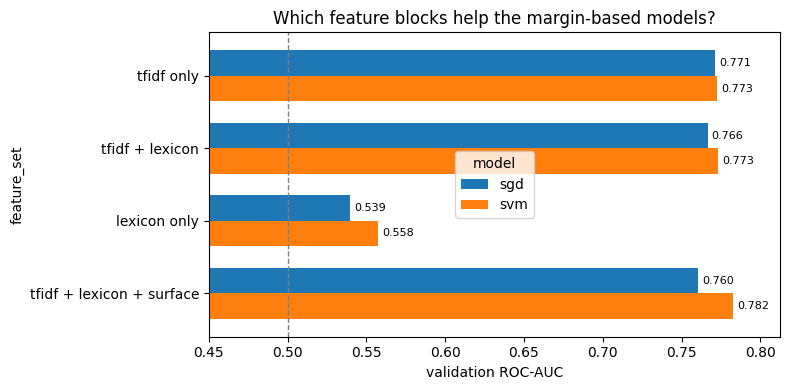

In [47]:
piv = cmp_df.pivot(index="feature_set", columns="model", values="val_auc").loc[list(FEATURE_SETS)]
ax = piv.plot.barh(figsize=(8, 4), width=0.7)
ax.axvline(0.5, ls="--", c="grey", lw=1); ax.set_xlim(0.45, max(0.8, piv.values.max() + 0.03))
ax.set_xlabel("validation ROC-AUC"); ax.set_title("Which feature blocks help the margin-based models?")
for c in ax.containers: ax.bar_label(c, fmt="%.3f", padding=3, fontsize=8)
ax.invert_yaxis(); plt.tight_layout(); plt.savefig(FIGURES / "M01_feature_sets.png", dpi=150); plt.show()

## 6. Parameter sweep, step 2 - tune hyper-parameters

On the best feature set from step 5:

* **Linear SVM** - `C` (the regularisation strength; small C = wider margin, simpler model; large C = fits training data harder).
* **SGD** - `alpha` (regularisation; the SGD analogue of 1/C) and the **learning-rate schedule** (`optimal`, or `adaptive` with a starting rate `eta0`).


In [48]:
SVM_GRID = [{"C": c} for c in (0.01, 0.03, 0.1, 0.3, 1.0)]
SGD_GRID = ([{"alpha": a, "learning_rate": "optimal"} for a in (1e-6, 1e-5, 1e-4)] +
            [{"alpha": a, "learning_rate": "adaptive", "eta0": e}
             for a in (1e-6, 1e-5, 1e-4) for e in (0.01, 0.1)])

Xtr_best = assemble(B_train, FEATURE_SETS[BEST_SET])
Xva_best = assemble(B_val,   FEATURE_SETS[BEST_SET])

def tune(kind, grid):
    out = []
    for p in grid:
        t0 = time.time()
        _, s = fit_score(kind, p, Xtr_best, y_train, Xva_best)
        out.append({**p, "val_auc": round(roc_auc_score(y_val, s), 4),
                    "val_acc": round(accuracy_score(y_val, (s >= 0).astype(int)), 4),
                    "fit_s": round(time.time() - t0, 1)})
    return pd.DataFrame(out).sort_values("val_auc", ascending=False).reset_index(drop=True)

svm_trials = tune("svm", SVM_GRID)
sgd_trials = tune("sgd", SGD_GRID)
svm_trials.to_csv(RESULTS / "svm_trials.csv", index=False)
sgd_trials.to_csv(RESULTS / "sgd_trials.csv", index=False)

def best_params(df, keys):
    """Top row of a trials table -> plain-Python parameter dict (NaN columns skipped)."""
    row, out = df.iloc[0], {}
    for k in keys:
        if k in df.columns and not pd.isna(row[k]):
            out[k] = row[k] if isinstance(row[k], str) else float(row[k])
    return out

BEST_SVM = best_params(svm_trials, ["C"])
BEST_SGD = best_params(sgd_trials, ["alpha", "learning_rate", "eta0"])
print("best SVM:", BEST_SVM, "  val AUC", svm_trials.iloc[0]["val_auc"])
print("best SGD:", BEST_SGD, "  val AUC", sgd_trials.iloc[0]["val_auc"])
svm_trials

best SVM: {'C': 0.1}   val AUC 0.7825
best SGD: {'alpha': 1e-05, 'learning_rate': 'optimal'}   val AUC 0.7602


,C,val_auc,val_acc,fit_s
0,0.10,0.7825,0.7133,19.2
1,0.30,0.7758,0.7066,54.1
2,0.03,0.7751,0.7072,13.3
3,0.01,0.7573,0.6923,8.0
4,1.00,0.7557,0.6900,48.8


In [49]:
sgd_trials

,alpha,learning_rate,val_auc,val_acc,fit_s,eta0
0,0.000010,optimal,0.7602,0.6951,2.5,NaN
1,0.000001,adaptive,0.7585,0.6929,2.4,0.01
2,0.000010,adaptive,0.7575,0.6923,2.5,0.01
3,0.000100,adaptive,0.7545,0.6857,2.4,0.01
4,0.000100,adaptive,0.7502,0.6820,2.5,0.10
5,0.000100,optimal,0.7499,0.6817,2.6,NaN
6,0.000010,adaptive,0.7457,0.6831,2.4,0.10
7,0.000001,optimal,0.7173,0.6599,2.5,NaN
8,0.000001,adaptive,0.6982,0.6452,2.2,0.10


## 7. Final models

Retrain both chosen configurations on the **full** `sarc_random/train` (when `FINAL_FULL_TRAIN` is on), refitting the TF-IDF / scalers on that data.
The decision threshold is picked on the full validation set, then test is scored **once**.

In [50]:
t0 = time.time()
if FINAL_FULL_TRAIN:
    fit_df, thr_df = train_full, val_full
    bb_final = BlockBuilder()
    B_fit = bb_final.fit_transform(fit_df)
    B_thr = bb_final.transform(thr_df)
else:                                   # QUICK mode: reuse the tuning matrices
    fit_df, thr_df, bb_final, B_fit, B_thr = train, val, bb, B_train, B_val

B_test = bb_final.transform(test)
cols = FEATURE_SETS[BEST_SET]
X_fit, X_thr, X_test = (assemble(B, cols) for B in (B_fit, B_thr, B_test))
y_fit, y_thr, y_test = fit_df["label"].to_numpy(), thr_df["label"].to_numpy(), test["label"].to_numpy()
print(f"features ready: fit {X_fit.shape}  thr {X_thr.shape}  test {X_test.shape}  ({time.time()-t0:.0f}s)")

FINAL = {}      # name -> dict(model, thr, test metrics)
for name, kind, params in [("Linear SVM", "svm", BEST_SVM), ("SGD (hinge)", "sgd", BEST_SGD)]:
    t0 = time.time()
    model = make_model(kind, **params).fit(X_fit, y_fit)
    thr = pick_threshold(y_thr, model.decision_function(X_thr))
    s_test = model.decision_function(X_test)
    FINAL[name] = {"model": model, "kind": kind, "params": params, "threshold": thr, "test_score": s_test,
                   "test_default": metrics(y_test, s_test, 0.0),
                   "test_at_precision_target": metrics(y_test, s_test, thr["threshold"]),
                   "fit_s": round(time.time() - t0, 1)}
    print(f"{name}: fitted in {FINAL[name]['fit_s']}s | threshold rule: {thr['rule']} -> {thr['threshold']:.4f}")

features ready: fit (639638, 299330)  thr (137066, 299330)  test (137065, 299330)  (38s)
Linear SVM: fitted in 94.5s | threshold rule: precision >= 0.75 -> 0.0037
SGD (hinge): fitted in 9.3s | threshold rule: precision >= 0.75 -> 0.0220


## 8. Test results (sarc_random/test, scored once)

In [51]:
rows = []
for name, f in FINAL.items():
    for label, key in [("default (score > 0)", "test_default"), (f"precision-target (val >= {TARGET_PRECISION})", "test_at_precision_target")]:
        m = f[key]
        rows.append({"model": name, "operating point": label, "threshold": m["threshold"],
                     "accuracy": m["accuracy"], "precision": m["precision"], "recall": m["recall"],
                     "f1": m["f1"], "roc_auc": m["roc_auc"], "pr_auc": m["pr_auc"]})
test_df = pd.DataFrame(rows)
display(test_df)

# sanity floor: accuracy of always guessing the majority class on this test set
majority_acc = round(float(max(y_test.mean(), 1 - y_test.mean())), 4)
print(f"majority-class baseline accuracy on test: {majority_acc}")

,model,operating point,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Linear SVM,default (score > 0),0.0000,0.7290,0.7532,0.6982,0.7247,0.8026,0.8153
1,Linear SVM,precision-target (val >= 0.75),0.0037,0.7290,0.7547,0.6956,0.7239,0.8026,0.8153
2,SGD (hinge),default (score > 0),0.0000,0.7159,0.7514,0.6631,0.7045,0.7860,0.7991
3,SGD (hinge),precision-target (val >= 0.75),0.0220,0.7154,0.7550,0.6555,0.7018,0.7860,0.7991


majority-class baseline accuracy on test: 0.5107


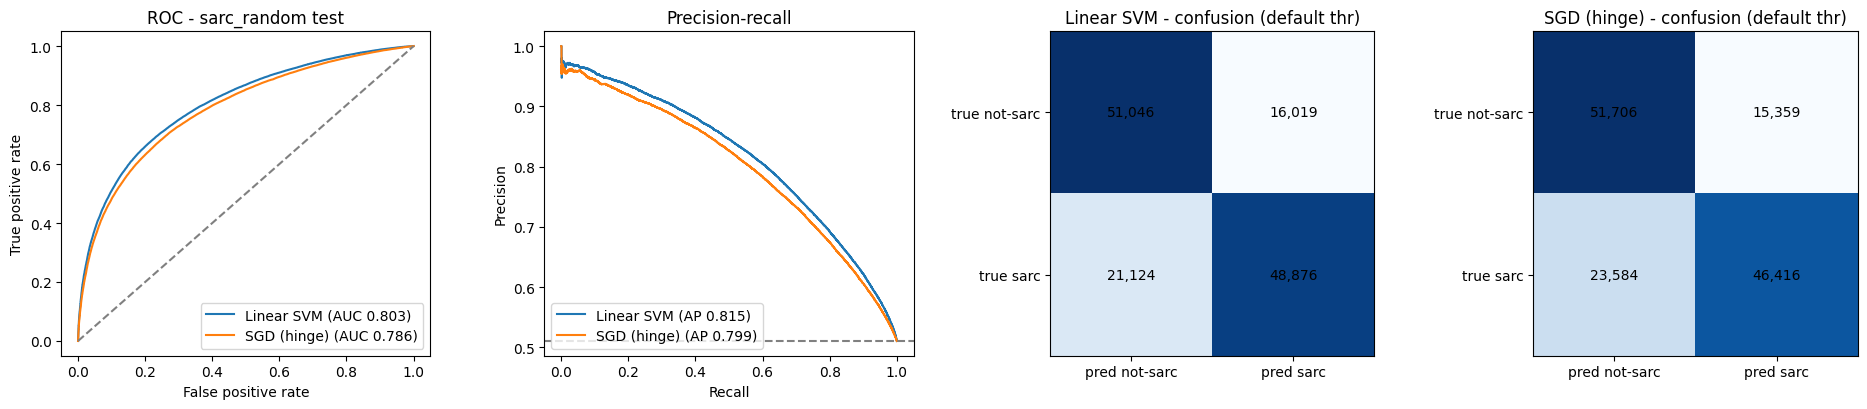

In [52]:
fig, (a1, a2, a3, a4) = plt.subplots(1, 4, figsize=(19, 4.2))
for name, f in FINAL.items():
    fpr, tpr, _ = roc_curve(y_test, f["test_score"]); a1.plot(fpr, tpr, label=f"{name} (AUC {f['test_default']['roc_auc']:.3f})")
    p, r, _ = precision_recall_curve(y_test, f["test_score"]); a2.plot(r, p, label=f"{name} (AP {f['test_default']['pr_auc']:.3f})")
a1.plot([0, 1], [0, 1], "--", c="grey"); a1.set(title="ROC - sarc_random test", xlabel="False positive rate", ylabel="True positive rate"); a1.legend(loc="lower right")
a2.axhline(y_test.mean(), ls="--", c="grey"); a2.set(title="Precision-recall", xlabel="Recall", ylabel="Precision"); a2.legend(loc="lower left")
for ax, (name, f) in zip((a3, a4), FINAL.items()):
    c = f["test_default"]["confusion"]
    cm = np.array([[c["tn"], c["fp"]], [c["fn"], c["tp"]]])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2): ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="black")
    ax.set(title=f"{name} - confusion (default thr)", xticks=[0, 1], yticks=[0, 1],
           xticklabels=["pred not-sarc", "pred sarc"], yticklabels=["true not-sarc", "true sarc"])
plt.tight_layout(); plt.savefig(FIGURES / "M02_test_curves.png", dpi=150); plt.show()

## 9. Testing on other datasets

The models trained on SARC are applied, unchanged, to the **test split** of four other datasets. Nothing is refitted and nothing is selected on these scores.

| Dataset (name in code) | What it is | Tests whether the model... |
|---|---|---|
| `tweeteval_irony` | TweetEval Irony (SemEval-2018 Task 3): tweets with human-checked labels | transfers from Reddit to Twitter |
| `figlang_reddit` | FigLang 2020 shared task, Reddit part: replies with their earlier conversation turns | works on other Reddit data that has a longer context |
| `figlang_twitter` | FigLang 2020 shared task, Twitter part: same format, from Twitter | works on Twitter conversations |
| `news_headlines` | News Headlines Dataset: The Onion (sarcastic) vs HuffPost (not sarcastic) | works on clean, edited writing instead of informal comments |

Columns that a dataset lacks (e.g. a headline has no parent comment) are filled with 0 by the feature builder.

  [surface] 5 columns absent in this corpus, filled with 0: ['parent_n_words', 'parent_n_chars', 'parent_is_empty', 'parent_jaccard', 'len_ratio_to_parent']


,target,model,n,positive_rate,roc_auc,accuracy,f1
0,figlang_reddit,Linear SVM,1756,0.497,0.7623,0.6879,0.6399
1,figlang_reddit,SGD (hinge),1756,0.497,0.7436,0.6549,0.5416
2,figlang_twitter,Linear SVM,1715,0.475,0.6505,0.6052,0.4657
3,figlang_twitter,SGD (hinge),1715,0.475,0.6127,0.5761,0.3937
4,tweeteval_irony,Linear SVM,780,0.397,0.5955,0.6090,0.3469
5,tweeteval_irony,SGD (hinge),780,0.397,0.5796,0.6090,0.2686
6,news_headlines,Linear SVM,4257,0.475,0.4453,0.5011,0.2039
7,news_headlines,SGD (hinge),4257,0.475,0.4547,0.5140,0.0642


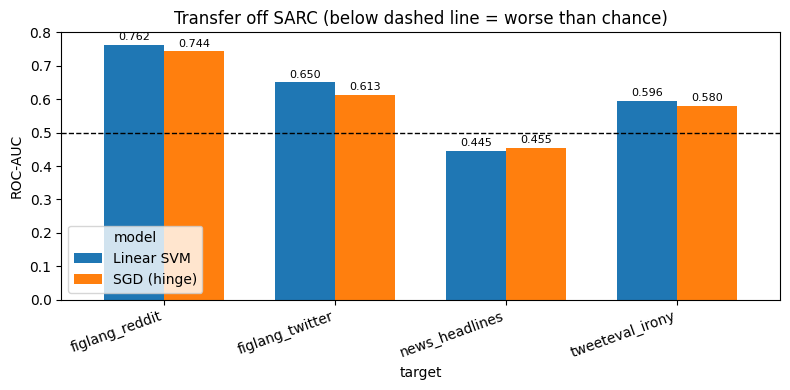

In [53]:
transfer_rows = []
for tgt in TRANSFER_TARGETS:
    try:
        df = load_split(tgt, "test")
    except Exception as e:
        print(f"skip {tgt}: {e}"); continue
    X = assemble(bb_final.transform(df), cols); y = df["label"].to_numpy()
    for name, f in FINAL.items():
        s = f["model"].decision_function(X)
        m = metrics(y, s, 0.0)
        transfer_rows.append({"target": tgt, "model": name, "n": m["n"], "positive_rate": round(float(y.mean()), 3),
                              "roc_auc": m["roc_auc"], "accuracy": m["accuracy"], "f1": m["f1"]})
transfer_df = pd.DataFrame(transfer_rows)
display(transfer_df)

if len(transfer_df):
    piv = transfer_df.pivot(index="target", columns="model", values="roc_auc")
    ax = piv.plot.bar(figsize=(8, 4), width=0.7); ax.axhline(0.5, c="black", ls="--", lw=1)
    ax.set_ylabel("ROC-AUC"); ax.set_title("Transfer off SARC (below dashed line = worse than chance)")
    for c in ax.containers: ax.bar_label(c, fmt="%.3f", fontsize=8, padding=2)
    plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.savefig(FIGURES / "M03_transfer.png", dpi=150); plt.show()

## 11. Save results

Outputs saved to: `results/margin-based/`, `figures/margin-based/`, and `models/margin-based/`. 

In [ ]:
import json
import joblib

if 'VERSIONS' not in globals():
    VERSIONS = {}
if 'transfer_df' not in globals():
    transfer_df = pd.DataFrame()

# Save CSV summaries
cmp_df.to_csv(RESULTS / "feature_set_comparison.csv", index=False)
test_df.to_csv(RESULTS / "test_leaderboard.csv", index=False)
if len(transfer_df): 
    transfer_df.to_csv(RESULTS / "transfer.csv", index=False)

summary = {
    "task": "sarcasm detection, sarc_random", 
    "seed": SEED, 
    "quick_mode": QUICK, 
    "versions": VERSIONS,
    "tuning_rows": {"train": int(len(train)), "val": int(len(val))},
    "final_fit_rows": int(len(fit_df)),
    "best_feature_set": BEST_SET,
    "feature_set_comparison": cmp_df.to_dict("records"),
    "models": {name: {"params": {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k, v in f["params"].items()},
                      "threshold_rule": f["threshold"],
                      "test_default": f["test_default"],
                      "test_at_precision_target": f["test_at_precision_target"]}
               for name, f in FINAL.items()},
    "transfer": transfer_df.to_dict("records") if len(transfer_df) else [],
}

# Write summary JSON to disk
(RESULTS / "evaluation.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")

# Dump vectorizer, scalers, and final models
joblib.dump({
    "tfidf": bb_final.tfidf, 
    "lex_scaler": bb_final.lex_scaler, 
    "surf_scaler": bb_final.surf_scaler,
    "feature_blocks": cols
}, MODELS / "feature_pipeline.joblib")

for name, f in FINAL.items():
    joblib.dump(f["model"], MODELS / f"{f['kind']}.joblib")

print("Saved successfully! Output directory contents:")
print("  " + "\n  ".join(sorted(p.name for p in RESULTS.iterdir())))

Saved successfully! Output directory contents:
  evaluation.json
  feature_set_comparison.csv
  sgd_trials.csv
  svm_feature_weights.csv
  svm_trials.csv
  test_leaderboard.csv
  transfer.csv
